# EDA: Exploratory Data Analysis

- tools: `pandas`, `seaborn`, & `matplotlib`
- concepts:
    - structure (including joins)
    - granularity
    - scope 
    - temporality
    - faithfulness
- EDA Case Studies:
    - Car Crashes
    - Steak Survey


<div class="alert alert-success">
The examples and data in this notebook are largely adapted from two places: (1) Jake VanderPlas' <a href="https://github.com/jakevdp/PythonDataScienceHandbook" class="alert-link">Python Data Science Handbook</a> and (2) Berkeley's <a href="https://www.textbook.ds100.org/ch/06/viz_intro.html" class="alert-link">Data 100 Textbook</a> (your TA, Sam, is an author on that book!!!). Feel free to check out these resources for more!
</div>

## Exploratory data analysis (EDA)

> an approach to completely and fully understand your dataset.

It requires a state of flexibility and a willingness to look for both:
- artifacts in the data we anticipate exist 
- artifacts that we don't expect / believe are there



## Setup

In [1]:
# Import seaborn and apply its plotting styles
import seaborn as sns
sns.set(style="white",font_scale=2)

# import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt

# make sure pandas is imported
import pandas as pd

# import numpy
import numpy as np

# set plotting size parameter
plt.rcParams['figure.figsize'] = (17, 7)

import warnings
warnings.filterwarnings('ignore')

# EDA

In the [Data 100 Textbook](https://www.textbook.ds100.org/ch/05/eda_intro.html), the authors state that with EDA, "We seek to understand the following properties about our data:

- Structure: the format of our data file.
- Granularity: how fine or coarse each row and column is.
- Scope: how (in)complete our data are.
- Temporality: how the data are situated in time.
- Faithfulness: how well the data captures "reality".

# Structure

What is the format of our data file?

<div class="alert alert-info">
The <b>structure</b> of your data describes the "shape" of the dataset. This refers to the format that the data are stored.
<div>

#### Questions to be able to answer about the structure of your dataset:
1. What format are the data in?
    - tabular (CSV, TSV, Excel, SQL)
    - nested (XML, JSON,)
2. Is each observation in a separate row? 
    - If not, can we get it into that format?
    - If the data are nested, how would we unnest the data
3. What variables (columns) do we have information about?
    - what `type` of information is in each column
    - Do we have all of the variables we need
4. Are the data spread across multiple tables? 
    - How do we want to join the data?
    

## Joins

Data are often spread across multiple tables of data, especially when the data are being retrieved from a relational database (i.e. SQL). *Joins* will help you get the data you need into a single DataFrame.

Let's look at an example.

In [2]:
people = pd.DataFrame(
    [["Joey",      "blue",    42,  "M"],
     ["Weiwei",    "blue",    50,  "F"],
     ["Joey",      "green",    8,  "M"],
     ["Karina",    "green",    7,  "F"],
     ["Nhi",       "blue",     3,  "F"],
     ["Sam",       "pink",   -42,  "M"]], 
    columns = ["Name", "Color", "Number", "Sex"])

people

,Name,Color,Number,Sex
0,Joey,blue,42,M
1,Weiwei,blue,50,F
2,Joey,green,8,M
3,Karina,green,7,F
4,Nhi,blue,3,F
5,Sam,pink,-42,M


In [3]:
email = pd.DataFrame(
    [["Deb",  "deborah_nolan@ucsd.edu"],
     ["Sam",  "samlau95@ucsd.edu"],
     ["John", "doe@nope.com"],
     ["Joey", "jegonzal@cs.ucsd.edu"],
     ["Weiwei", "weiwzhang@ucsd.edu"],
     ["Weiwei", "weiwzhang+123@ucsd.edu"],
     ["Karina", "kgoot@ucsd.edu"]], 
    columns = ["User Name", "Email"])

email

,User Name,Email
0,Deb,deborah_nolan@ucsd.edu
1,Sam,samlau95@ucsd.edu
2,John,doe@nope.com
3,Joey,jegonzal@cs.ucsd.edu
4,Weiwei,weiwzhang@ucsd.edu
5,Weiwei,weiwzhang+123@ucsd.edu
6,Karina,kgoot@ucsd.edu


In [9]:
people

,Name,Color,Number,Sex
0,Joey,blue,42,M
1,Weiwei,blue,50,F
2,Joey,green,8,M
3,Karina,green,7,F
4,Nhi,blue,3,F
5,Sam,pink,-42,M


A join between the two tables on the columns that contain the usernames will allow us to combine these two tables. 

To decide on what *type* of join we'll use, we must then decide how we want to handle people that appear in one table but not the other. (For example, Fernando appears in the `people` table but not the `email` table.)

We have several types of joins for each strategy of matching missing values.

## Inner Join

One of the more common joins is the inner join, where *any row that doesn't have a match is dropped in the final result*:

In [10]:
people

,Name,Color,Number,Sex
0,Joey,blue,42,M
1,Weiwei,blue,50,F
2,Joey,green,8,M
3,Karina,green,7,F
4,Nhi,blue,3,F
5,Sam,pink,-42,M


In [11]:
email

,User Name,Email
0,Deb,deborah_nolan@ucsd.edu
1,Sam,samlau95@ucsd.edu
2,John,doe@nope.com
3,Joey,jegonzal@cs.ucsd.edu
4,Weiwei,weiwzhang@ucsd.edu
5,Weiwei,weiwzhang+123@ucsd.edu
6,Karina,kgoot@ucsd.edu


In [9]:
# inner join
# Nhi, Deb and John don't appear
people.merge(email, how='inner', left_on='Name', right_on='User Name')

,Name,Color,Number,Sex,User Name,Email
0,Joey,blue,42,M,Joey,jegonzal@cs.ucsd.edu
1,Joey,green,8,M,Joey,jegonzal@cs.ucsd.edu
2,Weiwei,blue,50,F,Weiwei,weiwzhang@ucsd.edu
3,Weiwei,blue,50,F,Weiwei,weiwzhang+123@ucsd.edu
4,Karina,green,7,F,Karina,kgoot@ucsd.edu
5,Sam,pink,-42,M,Sam,samlau95@ucsd.edu


If the field you are joining on had the same name in both dataframe, you could use the 'on' parameters instead of 'left_on' and 'right_on'

## Join Types 
There are four major joins that you'll want to become familiar with:

<center><img src="joins.jpeg" width="60%" height="60%"></center>


Pandas **join** function versus **merge** function:
- **join** is used when the fields you're joining on are the indices. You don't need to specificy the field in this case; it's implicit.
- **merge** is used when fields you join on are columns in the dataframe.
- For the mix case, one field is an index and the other field is a column, use **merge** with either **left_index=True** or **right_index=True**

# Granularity
How fine or coarse is the data stored in each row and column?

<div class="alert alert-info">
The <b>granularity</b> of your data is what each observation in your data represents.
<div>

Often, the observation will be a **single individual** (i.e. information about each person who has called into a call center). 

Other times, it will be data collected about a **single individual at a particular time** (i.e. information about each call received on a given day) - Note that the same individual could be in this dataset multiple times.

Other times, each row will contain a **summary about a number of indidivuals** (i.e. total number of calls received at a call center each day) - Here, each row would contain summarized information about a whole bunch of people.

## Individual Level Granularity

In this example, we see that each observation represents a single individual.

In [11]:
calls = pd.DataFrame(
    [["Joey",      "suspected poisoning",  42,  "M"],
     ["Weiwei",    "ingested substance",   50,  "F"],
     ["Joey",      "chemical in eye",       8,  "M"],
     ["Karina",    "ingested substance",    7,  "F"],
     ["Nhi",       "ingested substance",    3,  "F"],
     ["Sam",       "chemical on skin",     42,  "M"]], 
    columns = ["Name", "Complaint", "Age", "Gender"])

calls

,Name,Complaint,Age,Gender
0,Joey,suspected poisoning,42,M
1,Weiwei,ingested substance,50,F
2,Joey,chemical in eye,8,M
3,Karina,ingested substance,7,F
4,Nhi,ingested substance,3,F
5,Sam,chemical on skin,42,M


## Group-Level Granularity

However often the data we're handed have observations (rows) that summarize information across many individuals.

In [152]:
calls_total = pd.DataFrame(
    [["2019-08-29", 100],
    ["2019-08-30",  212],
    ["2019-08-31",  88],
    ["2019-09-01",  160],
    ["2019-09-02",  122],
    ], 
    columns = ["Date", "Calls"])

calls_total

,Date,Calls
0,2019-08-29,100
1,2019-08-30,212
2,2019-08-31,88
3,2019-09-01,160
4,2019-09-02,122


#### Questions to be able to answer about the granularity of your dataset:
1. What does each record (row) represent?
2. Do all records uniformly represent the same level of granularity
   - are some rows individual-level, while others are summaries of the group? How will this be handled?
3. Were the data summarized or aggregated?
    - How were they grouped & summarized
    - What metrics were used for summarization (means and medians are common)
4. What aggregations/summarizations do we plan to do with these data?
    

# Scope

How (in)complete are our data?

<div class="alert alert-info">
The <b>scope</b> of your data describes how helpful these data are with respect to our data science question.
<div>

At this point, **descriptive statistics** & **exploratory visualizations** become pretty essential.

- Descriptive Statistics - help to summarize typical values and ranges for variables of interest
- Exploratory Visualizations - help us understand the distributions of individual variables and relationships between variables in our dataset

We'll also want to start to determine how frequently, for what variables, and why data are **missing**.

# Temporality
How are these data situated in time?

<div class="alert alert-info">
The <b>temporality</b> refers to how the data are situated in time. Specifically, we're interested in what data and time information are included in the dataset.
<div>


#### Questions to be able to answer about the temporality of your dataset:
1. What do reported times represent?
    - What does each date and time in the dataset mean? Time event occurred? Time reported?
    - Note that **timezones** & **Daylight Saving Time** are always important to consider.
2. How are the dates/times represented? What format are they in?
   - YYYY-MM-DD? Year? Time? Date & Time?
3. How are null timestamps represented? 
    - was a "random" date picked?
        - `Jan 1st 1990` <- Excel's default date
        - `Jan 1st, 1904` <- Excel's default date *on Mac*
        - `12:00am Jan 1st, 1970`<- [Unix Epoch for Timestamps](https://www.wikiwand.com/en/Unix_time#/Encoding_time_as_a_number)
    - `-999`, `NaN`, `NA`
4. What aggregations/summarizations do we plan to do with these data?
    

# Faithfulness
How well do these data reflect reality?


<div class="alert alert-info">
The <b>faithfulness</b> of your data is a determination of how trustworthy the data are.
<div>

#### Questions to be able to answer about the faithfulness of your dataset:
1. Are the values reasonable / what we expect? 
    - Unreasonable values examples: dates in the future, locations that don't exist, negative counts, wild outliers
2. Are there inconsistencies across tables?
    - Identifiers that don't match?
    - Date of Births that differ between two tables?
    - Any inconsistencies between values stored in more than one table?
3. Are there data entered by hand? These often contain inconsistencies.
4. Any obvious signs of falsification?
    - examples: repeated names, fake looking email addresses, repeated uncommon names or fields





# EDA Case Study: Car Crashes

Typically you won't be handed a dataset without any information about where the data came from or what question you want to ask. But, for the sake of this exercise, let's look at a dataset where we really don't have any information beyond what's in the dataset itself and see what we can figure out through EDA.

## The Data

So far, we've used dummy datasets to demonstrate concepts of EDA. Now, let's go through the whole process, working with *real* datasets for the remainder of this lecture.

We'll start with a dataset available by default from the `seaborn` package.

In [13]:
crashes = sns.load_dataset('car_crashes')

crashes.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


## Structure

In [14]:
crashes.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


At a glance and without any additional information, we can tell this is tabular data with observations in rows and variables in columns.

It appears that each row contains some sort of observation, so we don't have to change the general format of the dataset.

Often the first thing you'll want to know is how big the datset is.

In [154]:
## determine shape of dataset
crashes.shape

(51, 8)

### What type of variable is in each column?

In [22]:
crashes.dtypes

total             float64
speeding          float64
alcohol           float64
not_distracted    float64
no_previous       float64
ins_premium       float64
ins_losses        float64
abbrev             object
dtype: object

Ok, mostly continuos variables, except for `abbrev` which contains some type of string data.

## Granularity

In [9]:
# take a look at the data
crashes.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


By focusing more closely on the `abbrev` category, we get a sense for what each observation represents - each row includes information about car crashes *at the state level*.

But wait...let's return to the number of observations there are in the dataset.

In [10]:
## determine shape of dataset
crashes.shape

(51, 8)

There are 50 US states...why are there *51* observations? 

## Scope

In [11]:
crashes

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA
5,13.6,5.032,3.808,10.744,12.920,835.50,139.91,CO
6,10.8,4.968,3.888,9.396,8.856,1068.73,167.02,CT
7,16.2,6.156,4.860,14.094,16.038,1137.87,151.48,DE
8,5.9,2.006,1.593,5.900,5.900,1273.89,136.05,DC
9,17.9,3.759,5.191,16.468,16.826,1160.13,144.18,FL


Ah! Washington, DC is included in there.

We now have an understanding that we're working with a dataset summarized at the state/territory level. 

## Temporality?

This dataset includes no information about when these data were collected, what year/time period they represent. This would be important information if you truly wanted to use them in an analysis.

## Faithfulness?

Now, because we have very little information about where these data came from and not much is included in the documenation, right off the bat we should be wary. Nevertheless, we'll take a look to see how believable the values are within the dataset.

## Missing values?

In [25]:
null_rows = crashes.isnull().any(axis=1)
print(crashes[null_rows])

Empty DataFrame
Columns: [total, speeding, alcohol, not_distracted, no_previous, ins_premium, ins_losses, abbrev]
Index: []


Looks like there aren't any missing data in this dataset, which is a good start.

## Expected values? Wild outliers?

We'll look at each of the variables in the dataset to see if any thing looks *off*.

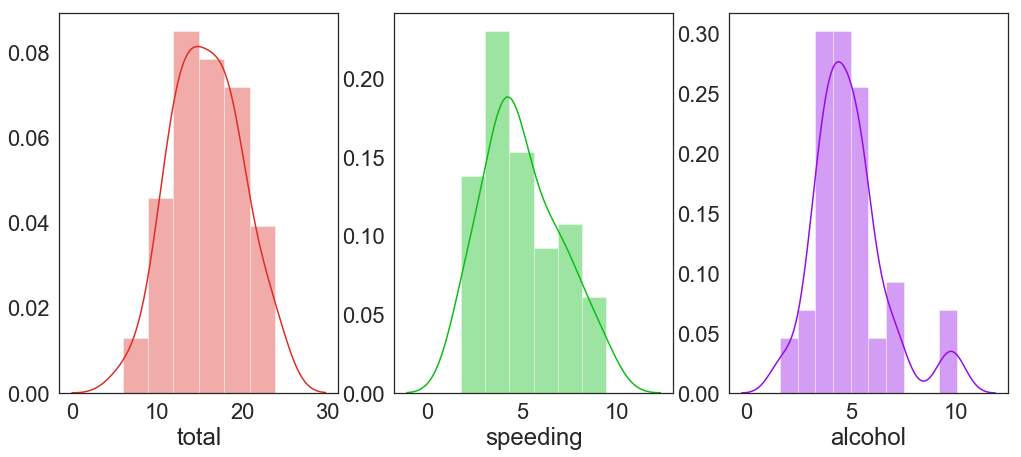

In [29]:
plt.subplot(1, 3, 1)
sns.distplot(crashes['total'], color = '#DE2D26')
plt.subplot(1, 3, 2)
sns.distplot(crashes['speeding'], color = '#0CBD18')
plt.subplot(1, 3, 3)
sns.distplot(crashes['alcohol'], color = '#940CE8')

We'll want to know which states/ territories have the outlier `alcohol` values

In [30]:
crashes[crashes['alcohol'] > 8]

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
26,21.4,8.346,9.416,17.976,18.190,816.21,85.15,MT
34,23.9,5.497,10.038,23.661,20.554,688.75,109.72,ND
40,23.9,9.082,9.799,22.944,19.359,858.97,116.29,SC


## Distraction & No Previous

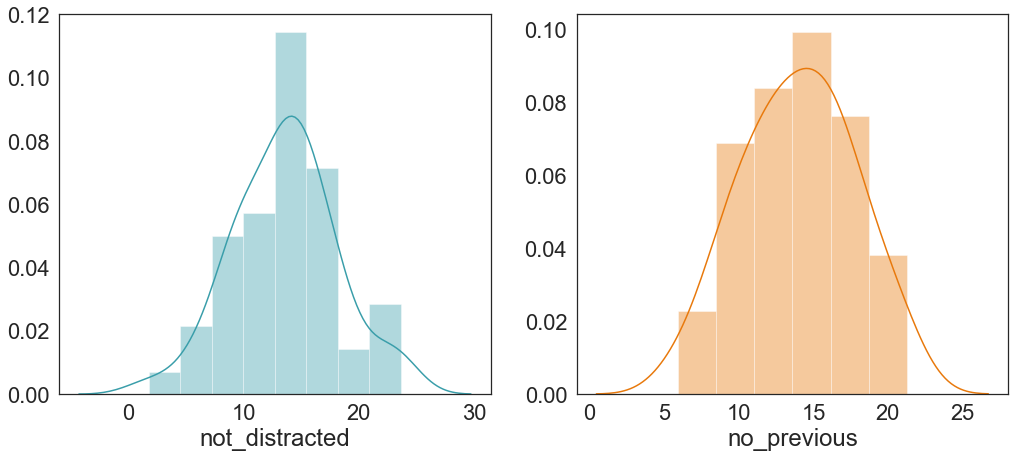

In [31]:
plt.subplot(1, 2, 1)
sns.distplot(crashes['not_distracted'], color = '#3A9EAA')
plt.subplot(1, 2, 2)
sns.distplot(crashes['no_previous'], color = '#E8790C')


### Relationship between these variables?

We can use scatterplots to start to get an understanding for how these values are related to one another.

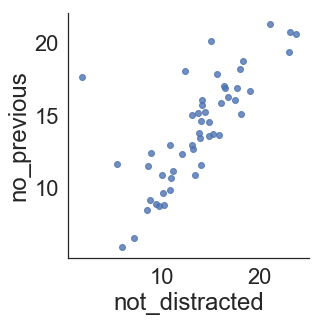

In [33]:
# scatterplot
sns.lmplot(x='not_distracted', y='no_previous', data=crashes, fit_reg=False);

Looks like there's a pretty clear relationship between these two variables...but what's going on with that point with a low `not_distracted` score and a high `no_previous` score?

In [34]:
## figure out who the outlier is
## ensure that each condition is in parentheses
crashes[(crashes['not_distracted'] < 5) & (crashes['no_previous'] > 16)]

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
24,17.6,2.64,5.456,1.76,17.6,896.07,155.77,MS


Okay, so Mississippi is behaving oddly with these two variables. Good to know.

## Insurance Premiums

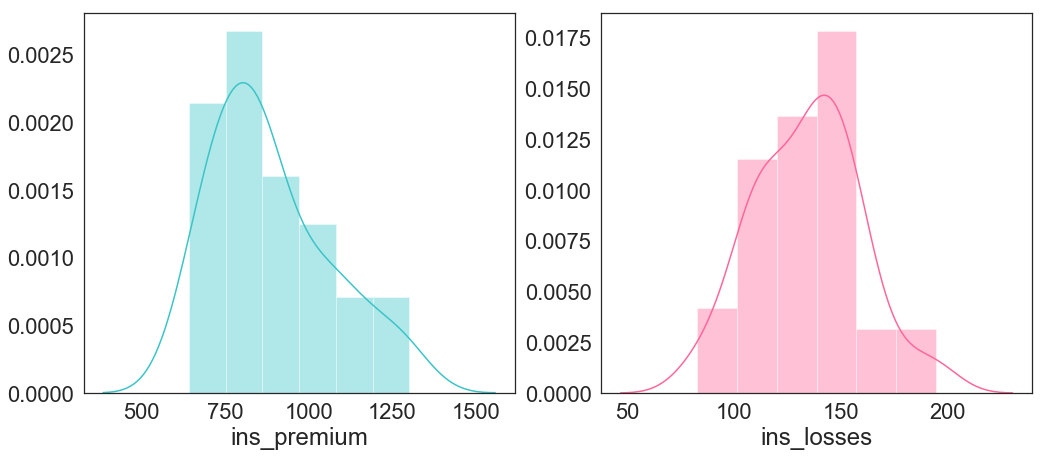

In [35]:
plt.subplot(1, 2, 1)  
sns.distplot(crashes['ins_premium'], color = '#3BC4C7')
plt.subplot(1, 2, 2)
sns.distplot(crashes['ins_losses'], color = '#FF6699')

No wild outlier values here, but some interesting shapes to the data, with a few states having both higher `ins_losses` and a few having higher `ins_premium`. We can use a scatterplot to see if the same states/territories are found at the high end for each variable.

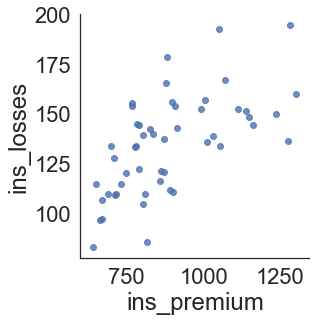

In [8]:
# scatterplot
sns.lmplot(x='ins_premium', y='ins_losses', data=crashes, fit_reg=False);

As in the last scatterplot we looked at, there appears to be a relationship between these variables; however, the correlation is lower than what we saw previously, suggesting a weaker relationship between the two variables. But, it does appear that the higher the premium the higher the losses.

## Scatterplot Matrix

We've looked at the histograms individually and scatterplots for the relationship, so we wanted to note that it is possible to combine the two in a single matrix plot.

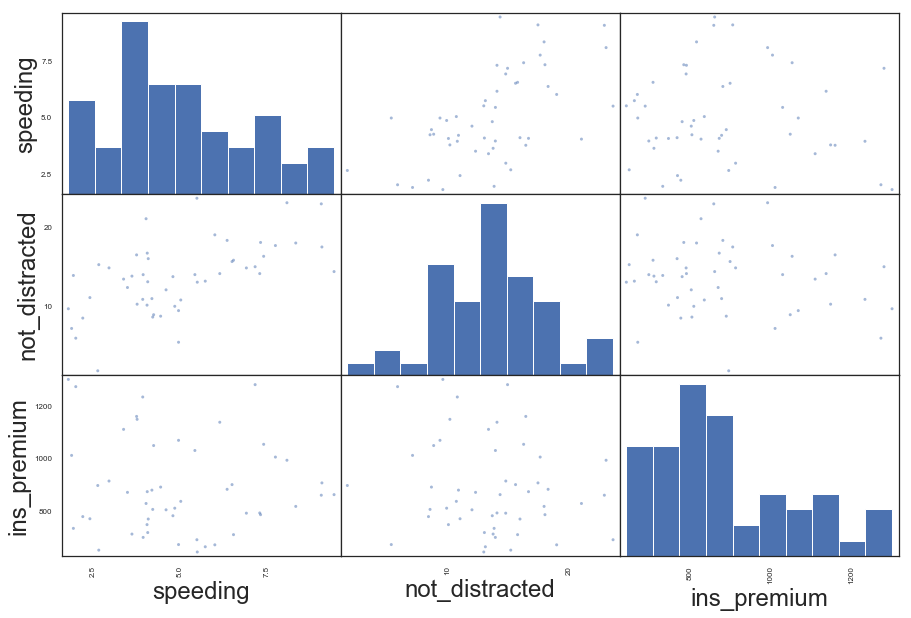

In [36]:
# generate scatter matrix
_ = pd.plotting.scatter_matrix(crashes[['speeding','not_distracted','ins_premium']], figsize=(15, 10))

# EDA Case Study: Steak Survey

Data available at [data.fivethirtyeight.com](https://data.fivethirtyeight.com/)

In [37]:
# Get CSV directly from URL
steak = pd.read_csv('https://raw.githubusercontent.com/fivethirtyeight/data/master/steak-survey/steak-risk-survey.csv')

steak

,RespondentID,"Consider the following hypothetical situations: <br>In Lottery A, you have a 50% chance of success, with a payout of $100. <br>In Lottery B, you have a 90% chance of success, with a payout of $20. <br><br>Assuming you have $10 to bet, would you play Lottery A or Lottery B?",Do you ever smoke cigarettes?,Do you ever drink alcohol?,Do you ever gamble?,Have you ever been skydiving?,Do you ever drive above the speed limit?,Have you ever cheated on your significant other?,Do you eat steak?,How do you like your steak prepared?,Gender,Age,Household Income,Education,Location (Census Region)
0,NaN,Response,Response,Response,Response,Response,Response,Response,Response,Response,Response,Response,Response,Response,Response
1,3.237566e+09,Lottery B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.234982e+09,Lottery A,No,Yes,No,No,No,No,Yes,Medium rare,Male,> 60,"$50,000 - $99,999",Some college or Associate degree,East North Central
3,3.234973e+09,Lottery A,No,Yes,Yes,No,Yes,Yes,Yes,Rare,Male,> 60,"$150,000+",Graduate degree,South Atlantic
4,3.234972e+09,Lottery B,Yes,Yes,Yes,No,Yes,Yes,Yes,Medium,Male,> 60,"$50,000 - $99,999",Bachelor degree,New England
5,3.234959e+09,Lottery B,No,Yes,No,No,Yes,Yes,Yes,Medium,Male,> 60,"$50,000 - $99,999",Graduate degree,Middle Atlantic
6,3.234955e+09,Lottery A,No,No,No,No,Yes,No,Yes,Medium rare,Male,18-29,"$0 - $24,999",Some college or Associate degree,West South Central
7,3.234955e+09,Lottery A,No,Yes,No,No,Yes,Yes,No,NaN,Male,> 60,"$150,000+",Graduate degree,New England
8,3.234955e+09,Lottery A,No,Yes,Yes,Yes,Yes,No,Yes,Medium rare,Male,18-29,"$25,000 - $49,999",Some college or Associate degree,West North Central
9,3.234953e+09,Lottery A,Yes,Yes,Yes,No,Yes,No,Yes,Medium,Male,18-29,"$50,000 - $99,999",Bachelor degree,East North Central


These data were used in the [FiveThirtyEight](https://fivethirtyeight.com) article: *[How Americans Like Their Steak](https://fivethirtyeight.com/features/how-americans-like-their-steak/)*

## Structure

We can see that these data are tabular data, with observations in rows and variables in columns.

In [38]:
## determine shape of dataset
steak.shape

(551, 15)

Here, it appears that there are 551 observations. However, we notice off the bat that the first row should likely be removed from the dataset, as it only includes the word "Response".

What about the first row?

In [39]:
# remove first row
steak  = steak.iloc[1:]

steak.head()

,RespondentID,"Consider the following hypothetical situations: <br>In Lottery A, you have a 50% chance of success, with a payout of $100. <br>In Lottery B, you have a 90% chance of success, with a payout of $20. <br><br>Assuming you have $10 to bet, would you play Lottery A or Lottery B?",Do you ever smoke cigarettes?,Do you ever drink alcohol?,Do you ever gamble?,Have you ever been skydiving?,Do you ever drive above the speed limit?,Have you ever cheated on your significant other?,Do you eat steak?,How do you like your steak prepared?,Gender,Age,Household Income,Education,Location (Census Region)
1,3.237566e+09,Lottery B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.234982e+09,Lottery A,No,Yes,No,No,No,No,Yes,Medium rare,Male,> 60,"$50,000 - $99,999",Some college or Associate degree,East North Central
3,3.234973e+09,Lottery A,No,Yes,Yes,No,Yes,Yes,Yes,Rare,Male,> 60,"$150,000+",Graduate degree,South Atlantic
4,3.234972e+09,Lottery B,Yes,Yes,Yes,No,Yes,Yes,Yes,Medium,Male,> 60,"$50,000 - $99,999",Bachelor degree,New England
5,3.234959e+09,Lottery B,No,Yes,No,No,Yes,Yes,Yes,Medium,Male,> 60,"$50,000 - $99,999",Graduate degree,Middle Atlantic


### Data Types

In [40]:
steak.dtypes

RespondentID                                                                                                                                                                                                                                                                         float64
Consider the following hypothetical situations: <br>In Lottery A, you have a 50% chance of success, with a payout of $100. <br>In Lottery B, you have a 90% chance of success, with a payout of $20. <br><br>Assuming you have $10 to bet, would you play Lottery A or Lottery B?     object
Do you ever smoke cigarettes?                                                                                                                                                                                                                                                         object
Do you ever drink alcohol?                                                                                                                       

## Granularity?

These data appear to be individual-level data, with each row including survey responses from a single respondent. 

## Scope?

To determine how applicable these data are to answering our question of interest, we first have to define our question of interest. 

For our purposes here, our question will be:

> How do Americans prefer their steak cooked? 

(Note: this is a more general question than was asked and answered in FiveThirtyEight's article)


Answering this requires understanding a bit about how these data were generated from a SurveyMonkey Audience poll. 

*"On May 7 and 8, \[FiveThirtyEight\] ran a survey testing how 550 people interpret and evaluate risk." In this survey they happened to ask how Americans prefer their steak.*

We can thus explore the question above using these data.

This may not be a perfectly representative sample of Americans & is biased toward those who participate in SurveyMonkey Audience polls; however, with 551 responses, we can *start* to answer our question of interest.

## Temporality?

While not encoded in the data, we know from the article that these data were collected on May 7th and 8th, 2014. Thus, conclusions are most applicable to feelings in 2014, although there is no obvious reason why feelings about steak preference would have strongly changed since then.

## Faithfulness?

## Missing values?

In [42]:
null_rows = steak.isnull().any(axis=1) 
steak[null_rows].shape

(219, 15)

Looks like are a number of places where no data were reported, but we *really* care about the steak preference variable...so let's just focus on that variable.

In [45]:
null_steak = steak['How do you like your steak prepared?'].isnull()

# get an idea of how many individuals didn't state their steak preference
print(np.sum(null_steak))


118


In [46]:
# proportion missing
np.sum(null_steak) / len(steak.index)

0.21454545454545454

Well, that's good to know. 118 of the 551 respondents (21.45%!) did not respond to the steak preference question. We don't know why this information is missing, but that's a lot of the survey respondents. In an ideal world, we'd want to get more information about *why* these data are missing and whether or not the data are *missing at random*.

## Expected values? Wild outliers?

Among the data we do have, let's see what values are there for steak preference.

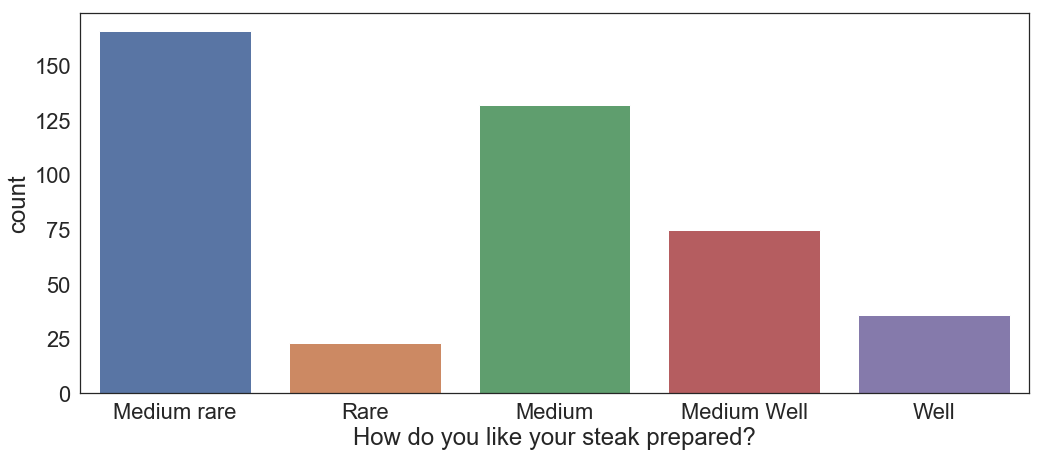

In [47]:
# plot steak preference
sns.countplot(x='How do you like your steak prepared?', data=steak);

While the axis isn't ordered as we would like, we do see that "Medium rare" is the most popular, while the extremes "Rare" and "Well" are the least popular.

### Ordering the x-axis

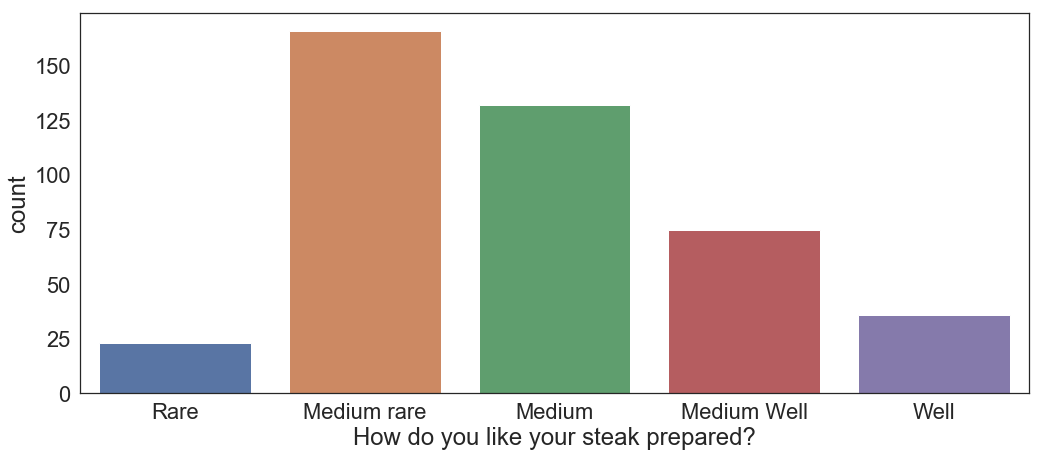

In [48]:
# fix order on x-axis
sns.countplot(x='How do you like your steak prepared?', 
              data=steak, 
              order=[ "Rare", "Medium rare", "Medium", "Medium Well", "Well"])


That's better!

## Relationship to other variables?

While we're primarily interested in the variable `How do you like your steak prepared?`, you'll want to get a deeper understanding of who is represented in your dataset.

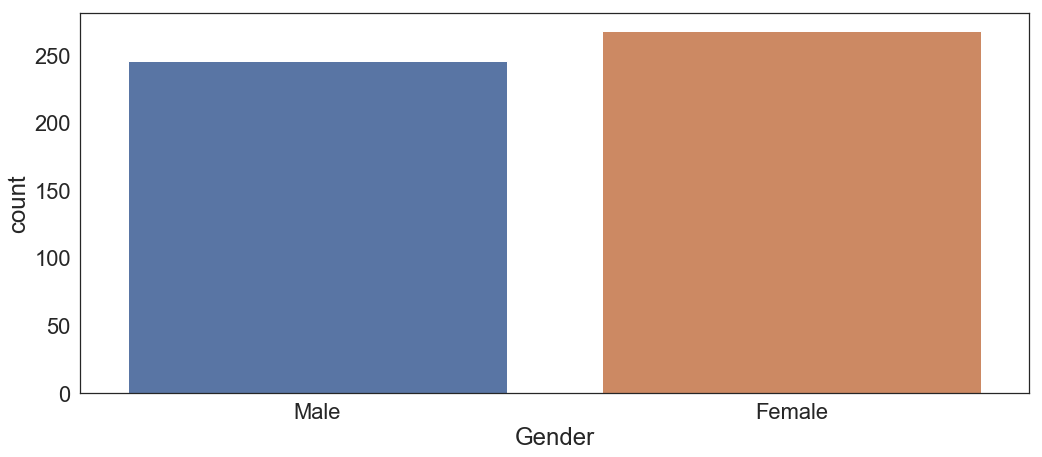

In [49]:
sns.countplot(x='Gender', data=steak);

Well, we're pretty balanced between "Males" and "Females", but without seeing the survey, we don't know if any other options for Gender were provided. Always important to keep in mind...you may not have the full story here.

### Gender Effect?

Let's see if there's a difference in steak preference by Gender.

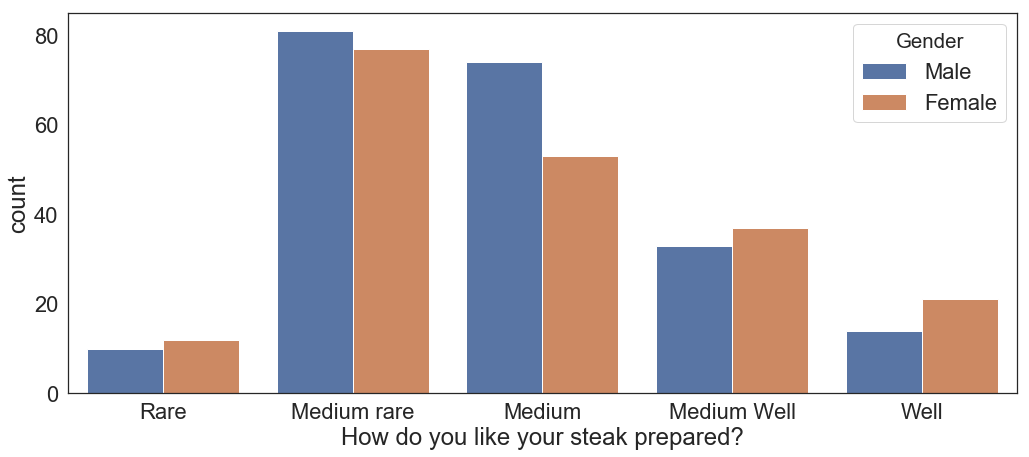

In [50]:
# Specify second variable with `hue`
sns.countplot(x='How do you like your steak prepared?', 
              hue='Gender', 
              data=steak,
              order=[ "Rare", "Medium rare", "Medium", "Medium Well", "Well"]);

Interesting! There seems to be a large discrepancy between Genders for those who prefer their steaks "Medium", with more males than preferring steaks "Medium". Note that this isn't just an effect of individuals sampled, as more females are included than males among the respondants. 

### Age Effect?

Let's see if there's a difference in steak preference by Age.

We don't have individual's actual age, just their age range, so we'll first look at that.

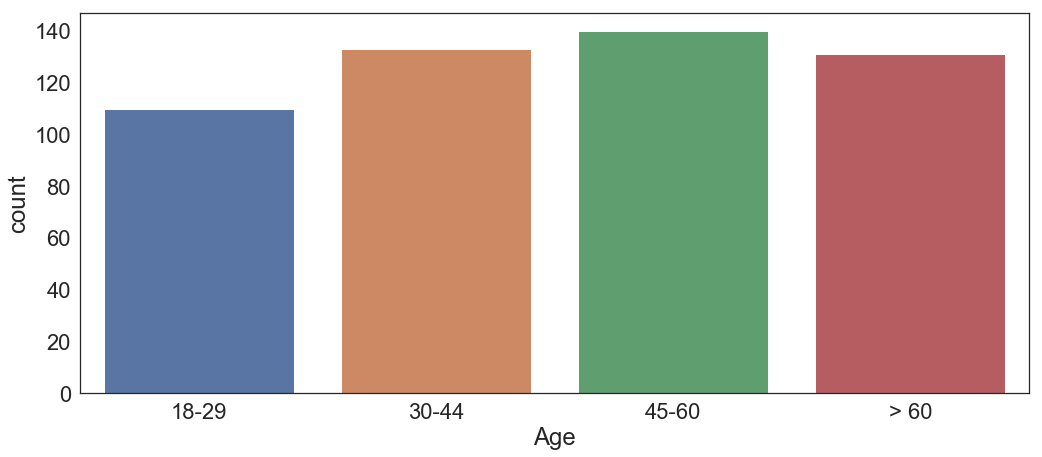

In [179]:
# Age distribution
sns.countplot(x ='Age', 
              data = steak, 
              order = ["18-29", "30-44", "45-60", "> 60"]);

Pretty even distribution, with a few more individuals in the 45-60 age range than in the other ranges. Fewer 18-29 year olds responded in general.

With that in mind, let's look at Age's relationahip with steak preference.

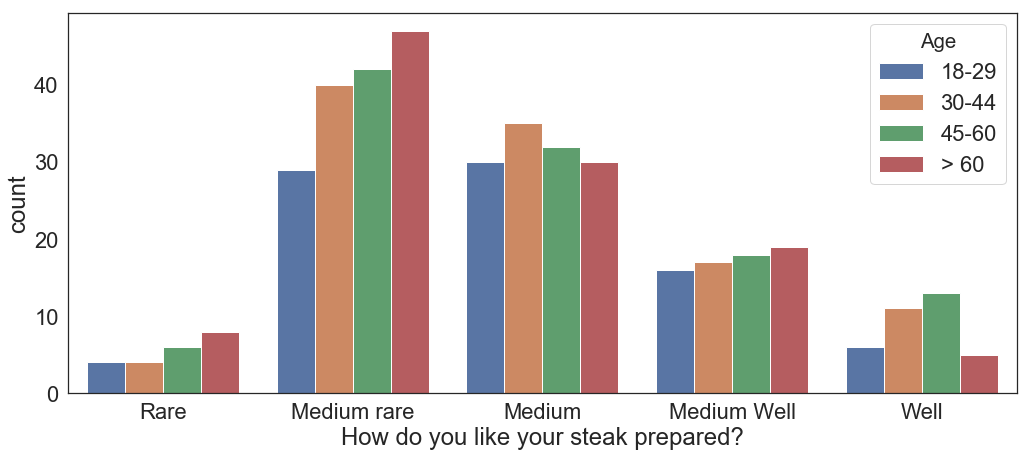

In [51]:
# Specify second variable with `hue`
sns.countplot(x='How do you like your steak prepared?', 
              hue='Age', 
              data= steak, 
              order= ["Rare", "Medium rare", "Medium", "Medium Well", "Well"],
              hue_order = ["18-29", "30-44", "45-60", "> 60"]);

There doesn't, at a glance appear to be a huge effect by age, but is this really the best way to answer this question? That's a lot of comparisons to make your eyes do. What if we change the plot up a little bit...

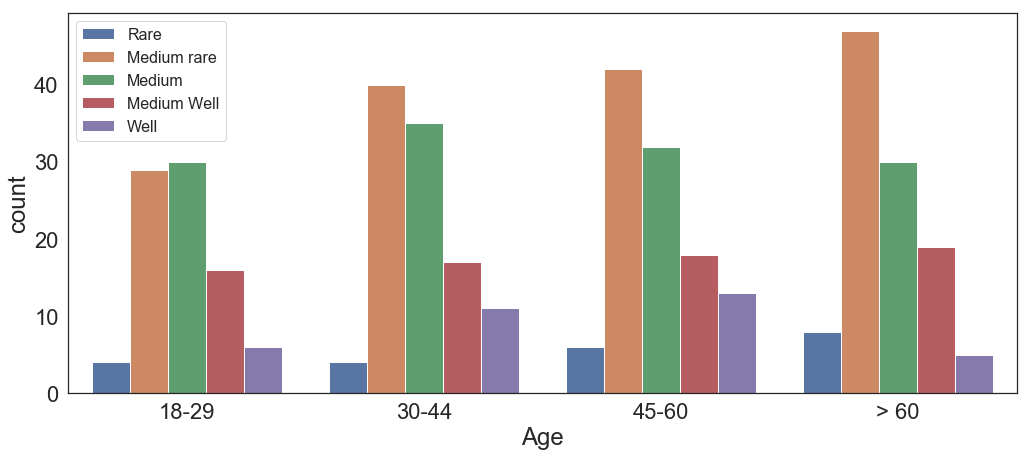

In [52]:
sns.countplot(x='Age', 
              hue='How do you like your steak prepared?', 
              data= steak, 
              hue_order= ["Rare", "Medium rare", "Medium", "Medium Well", "Well"],
              order = ["18-29", "30-44", "45-60", "> 60"])
plt.legend(fontsize='16');


Here, with age on the x-axis, it becomes pretty clear that the distribution of preference within each age group is pretty consistent. 

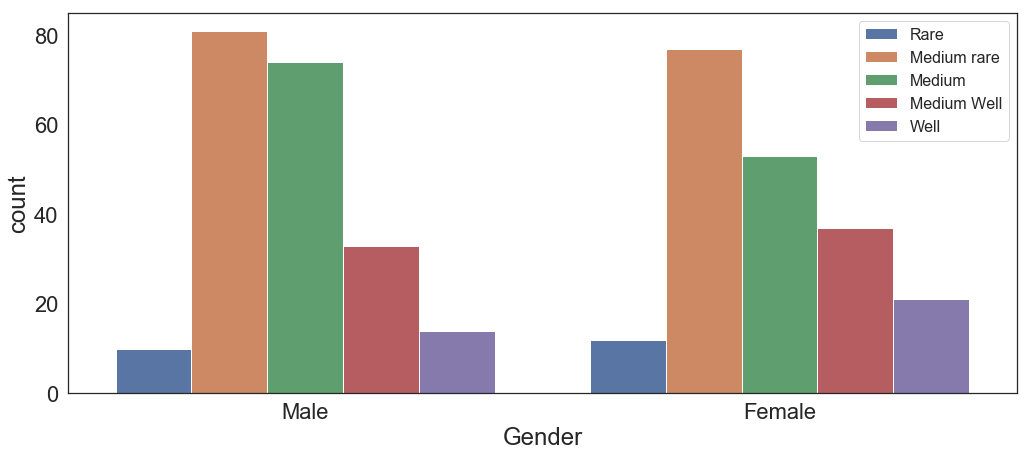

In [189]:
sns.countplot(hue ='How do you like your steak prepared?', 
              x ='Gender', 
              data=steak,
              hue_order=[ "Rare", "Medium rare", "Medium", "Medium Well", "Well"])
plt.legend(fontsize='16');

The same argument can be made for looking at the relationship between steak preference and gender. Here, when we flip how the relationship is plotted, we see that the shape is similar between Males and Females. We still see the fact that Males tend to prefer Medium steak more than females, as we saw above. 

It all comes down to what question you're asking and how you should present your data.